# **Financial Stock Trading using Reinforcement Learning**

In this lab I will learn how to apply Deep Reinforcement Learning(DRL) techniques to the domain of financial trading. I will work with a custom trading environment based on historical stock data and implement a Deep-Q-Network (DQN) agent to make intelligent buy, sell, or hold decisions. I will practice important ML steps such as data normalization, environment setup following OpenAI Gym standarts, building a neural network to estimate action values, and training the agent through interaction with the environment. By the end of this lab, I will understand how to structure a complete DRL pipeline for sequential decision-making tasks, how rewards shape the learning behaviour of agents, and how to evaluate trading performance using financial and statistical measures like total rewardsm profit percentages, and success rates.

# Setup the Model
This code defines a Deep Q-Network (DQN) model using PyTorch. The DQN class is a simple feedforward neural network that takes the current state of the environment as input and predicts Q-values for each possible action.

The network architecture includes:


*   An input layer that connects to the first hidden layer with 64 neurons.
*   A second hidden layer, also with 64 neurons.
*   An output layer that produces one Q-value for each possible action.

In the forward methos, the input data passes through two fully connected layers with ReLU activation functions, introducing non-linearity, and finally outputs the raw Q-values (without activation) for all actions. These Q-values help the agent decide which action is most valuable at any given state.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

class DQN(nn.Module):
  # Initializes the layers of the neural network
  def __init__(self, input_dim, output_dim):
    super(DQN, self).__init__()
    # First hidden layer takes the state (market window) and outputs 64 features
    self.fc1 = nn.Linear(input_dim, 64)
    # Second hidden layer processes those 64 features
    self.fc2 = nn.Linear(64, 64)
    # Output layer produces a Q-value for each possible action (Buy, Hold, Sell)
    self.out = nn.Linear(64, output_dim)

# Defines how data flows through the network
  def forward(self, x):
    # ReLU (Rectified Linear Unit) activation introduces non-linearity
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    # Returns the raw Q-values for the agent to evaluate
    return self.out(x)

# Setup the Agent
This code defines the DGNAgent, which controls how the reinforcement learning agent interacts with the environment, chooses actions, learns from experience, and updates its decision-making model.


*   In the init method, the agent sets up its memory buffer (for storing past experiences), learning parameters (like discount factor gamma and exploration probability epsilon), and creates a Deep Q-Network (DQN) model, optimizer, and loss function for training.
*   The choose_action method selects an action based on an epsilon-greedy strategy: it either explores randomly or chooses the action with the highest predicted Q-value.
*   The store method saves experiences (state, action, reward, next state, and done flag) into the memory buffer for later training.

*   The train method samples a batch of past experiences, calculates predicted Q-values, computes target Q-values based on rewards and next states, measures the difference(loss) between predicted and target Q-values, and updates the neural network by backpropagation. It also decays epsilon over time to gradually shift from exploration to explotation.


In [12]:
import random
import numpy as np
from collections import deque

class DQNAgent:
    def __init__(self, state_dim, action_dim):
      self.state_dim = state_dim
      self.action_dim = action_dim

      # Replay buffer scores up to 10,000 past steps to learn from
      self.memory = deque(maxlen=10000) # Replay buffer
      self.batch_size = 64

      # Gamma determmines how much the agent cares about long-term future rewards
      self.gamma = 0.99 # Discount factor
      # Epsilon controls the exploration vs. explotation trade-off
      self.epsilon = 1.0 # Exploration probability
      self.min_epsilon = 0.01
      # Epsilon decays over time, meaning the agent explores less as it gets smarter
      self.epsilon_decay = 0.9999

      self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
      self.model = DQN(state_dim, action_dim).to(self.device)
      # Adam optimizer tweaks the network weights to minimize errors
      self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
      self.loss_fn = nn.MSELoss()

    # The decision-making progress
    def choose_action(self, state):
      # Explore: pick a random action
      if random.random() < self.epsilon:
        return random.randrange(self.action_dim)
      # Exploit: pick the action with the highest predicted Q-value
      else:
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        q_values = self.model(state)
        return torch.argmax(q_values).item()

    # Saves an experience into the replay buffer
    def store(self, state, action, reward, next_state, done):
      self.memory.append((state, action, reward, next_state, done))

    # The learning mechanisn
    def train(self):
        # Wait until we have enough memories to form a batch
        if len(self.memory) < self.batch_size:
          return

        # Sample a random batch of memories
        batch = random.sample(self.memory, self.batch_size)
        # Filter out experiences where next_state is None
        batch = [(s, a, r, ns, d) for s, a, r, ns, d in batch if ns is not None and s is not None]
        if not batch:
          return

        # Unpack the batch into separate lists
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert to PyTorch tensors for network processing
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # What the network currently predicts the Q-values are
        q_values = self.model(states).gather(1, actions)
        # What the network predicts for the NEXT state
        next_q_values = self.model(next_states).max(1)[0].unsqueeze(1)

        # The Bellman Equation: The target is the immediate reward + discounted future potential
        targets = rewards + self.gamma * next_q_values * (1 - dones)

        # Calculate the error between prediction and target
        loss = self.loss_fn(q_values, targets)

        # Backpropogation: Adjust the network's weights to reduce the error
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Gradually reduce epsilon to shift from exploration to explotation
        if self.epsilon > self.min_epsilon:
          self.epsilon *= self.epsilon_decay






# Training the Agent
This code defines the training loop for a DQN agent in the stock trading environment.
The train_dqn function runs for a given number of episodes.


*   At the start of each episode, the environment is reset to a new starting point, and the agent begins with an empty total reward.

  * Inside each episode, the agent repeatedly:

  * Chooses an action based on the current state,

  * Takes that action in the environment and receives a reward and the next state,

  * Stores the experience in memory,

  * Trains its neural network using random samples from the past experiences (experience replay).






In [13]:
def train_dqn(env, agent, episodes = 500):
  rewards_per_episode = []

  for episode in range(episodes):
    state = env.reset()
    total_reward = 0
    done = False

    while not done:
      action = agent.choose_action(state)
      next_state, reward, done, _ = env.step(action)
      agent.store(state, action, reward, next_state, done)
      agent.train()


      state = next_state
      total_reward += reward

    rewards_per_episode.append(total_reward)
    print(f"Episode: {episode + 1}/{episodes} - Total Reward: {total_reward:.2f} - Epsilon: {agent.epsilon:.3f}")

  return rewards_per_episode

# Setup Training Environment
This code defines the StockTradingEnv, a custom trading environment compatible with OpenAI Gym. It simulates stock market behaviour to let a reinforcement learning agent practice trading.



*   In the **init** method, the environment loads selected stock price features(Open, High, Low, Last, Close), sets the action space(Buy, Hols, Sell), and defines the observation space as a flattened window of recent stock prices.
*  The **reset** method starts a new trading episode from a random point in the historical data and resets the agent's trading position.
* The **_get_state** method provides the agent with a fixed-size window of recent stock prices, flattened into 1D input array.
* The **step** methos executes the agent's choosen action:

* If buying or selling, it updates the trading position and calculates the reward based on price changes and trading commission costs.
* The environment moves forward one time step and checks if the episode should end.
* The agent's goal is to maximize cumulative rewards by making profitable trading decisionds based on the observed stock data.



In [14]:
from ast import NodeTransformer
import pandas as pd
import gymnasium
import numpy as np
import random

class StockTradingEnv(gymnasium.Env):
  def __init__(self, data, window_size = 10, commision=0.001):
    super(StockTradingEnv, self).__init__()
    # Use all provided stock index columns for the environment
    self.data = data
    self.window_size = window_size
    self.commision = commision
    self.current_step = self.window_size

    self.action_space = gymnasium.spaces.Discrete(3)  # Buy, Hold, Sell
    self.observation_space = gymnasium.spaces.Box(low=0, high=1, shape=(self.window_size * len(self.data.columns),), dtype=np.float32)  # Adjust observation space

    self.position = 0 # +1 for buy, -1 for sell, 0 for neutral
    self.entry_price = 0

  def reset(self):
    self.current_step = random.randint(self.window_size, len(self.data) - self.window_size - 1)
    self.position = 0
    self.entry_price = 0
    return self._get_state()

  def _get_state(self):
    state = self.data.iloc[self.current_step - self.window_size:self.current_step].values.flatten()
    return state

  def step(self, action):
    # Check if current step is within bounds before accessing data
    if self.current_step >= len(self.data):
      # If out of bounds, signal the end of the episode
      return None, 0, True, {} # next_state, reward, done, info

    # Use 'FTSE' as the reference for current price for reward calculation
    current_price = self.data.iloc[self.current_step]['FTSE']
    reward = 0

    # Applying trading logic
    if action == 0:  # Buy
      if self.position == 0:  # Flat: Open a Long
        self.position = 1
        self.entry_price = current_price
      elif self.position == -1:  # Short: Buy to close the short
        reward = self.entry_price - current_price - (self.commision * current_price)
        self.position = 0

    elif action == 1:  # Hold
      pass

    elif action == 2:  # Sell
      if self.position == 0:  # Flat:Open a Short
        self.position = -1
        self.entry_price = current_price
      elif self.position == 1: # Long: Sell to ckose the long
        reward = current_price - self.entry_price - (self.commision * current_price)
        self.position = 0

    self.current_step += 1
    done = self.current_step >= len(self.data)

    next_state = self._get_state() if not done else None # Ensure next_state is None if done
    return next_state, reward, done, {}

# Exploratory Data Analysis


*   Read the data and present its Summary Statistics
*   Plot closing price over time
*   Distribution plots for important columns



In [17]:
from google.colab import files
uploaded = files.upload()

Saving EuStockMarkets.csv to EuStockMarkets.csv


Once the upload is complete, I can re-run the cell with the `pd.read_csv('EuStockMarkets.csv')` command to load the data.

First 5 rows of the dataset:
   rownames      DAX     SMI     CAC    FTSE
0         1  1628.75  1678.1  1772.8  2443.6
1         2  1613.63  1688.5  1750.5  2460.2
2         3  1606.51  1678.6  1718.0  2448.2
3         4  1621.04  1684.1  1708.1  2470.4
4         5  1618.16  1686.6  1723.1  2484.7

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860 entries, 0 to 1859
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  1860 non-null   int64  
 1   DAX       1860 non-null   float64
 2   SMI       1860 non-null   float64
 3   CAC       1860 non-null   float64
 4   FTSE      1860 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 72.8 KB
None

Summary Statistics:
          rownames          DAX          SMI          CAC         FTSE
count  1860.000000  1860.000000  1860.000000  1860.000000  1860.000000
mean    930.500000  2530.656882  3376.223710  2227.828495  3565.643172
std     537.08006

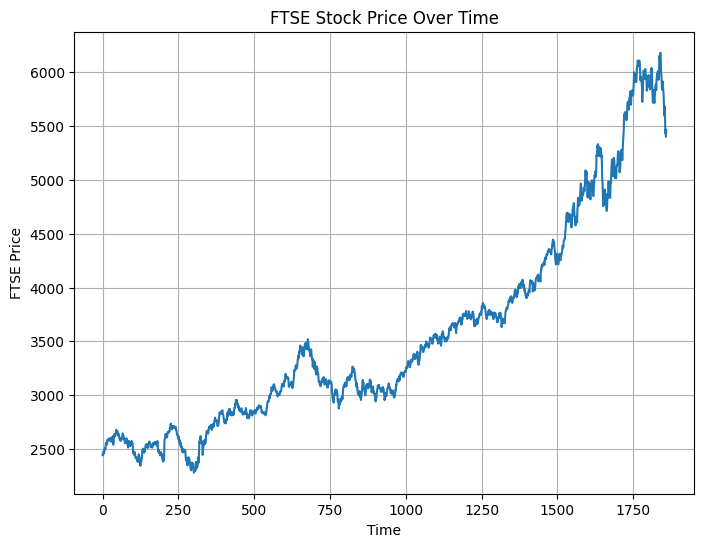

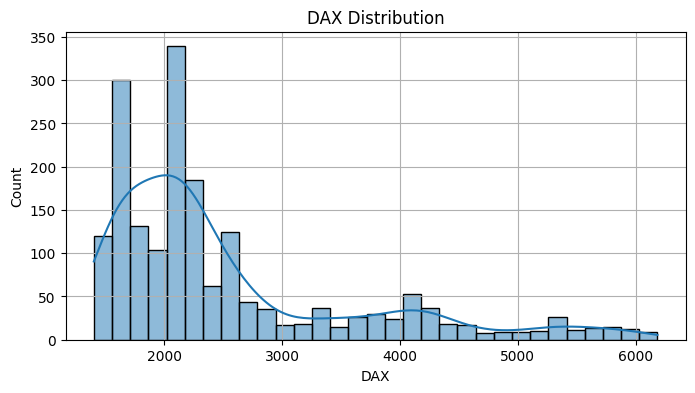

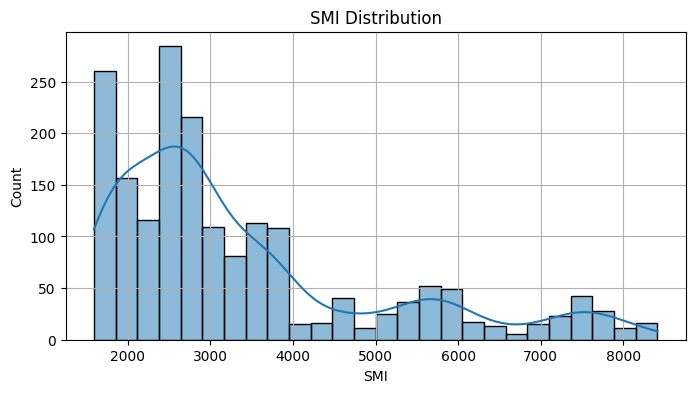

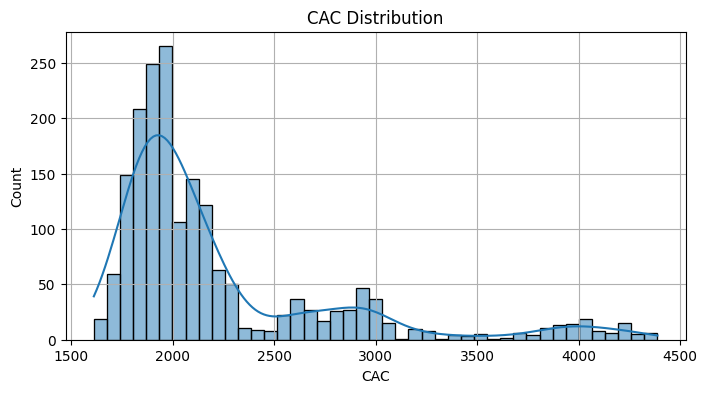

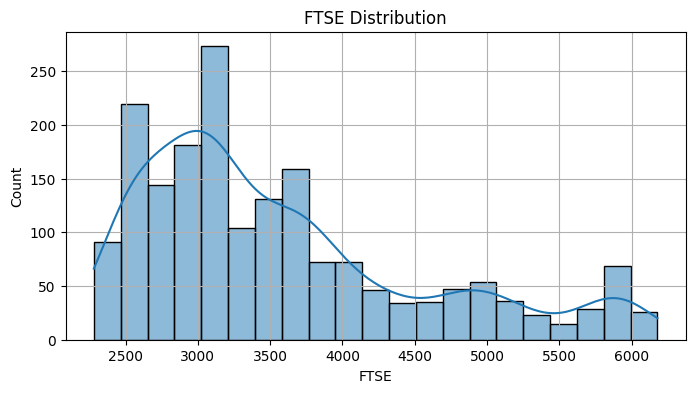

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
data = pd.read_csv('EuStockMarkets.csv')

# Basic overview
print("First 5 rows of the dataset:")
print(data.head())

print("\nDataset Info:")
print(data.info())

print("\nSummary Statistics:")
print(data.describe())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Display available columns
print("\nAvailable Columns:")
print(data.columns)

# Plot closing price over time (using 'DAX' as an example)
if 'FTSE' in data.columns:
  plt.figure(figsize=(8, 6))
  plt.plot(data['FTSE'])
  plt.title('FTSE Stock Price Over Time')
  plt.xlabel('Time')
  plt.ylabel('FTSE Price')
  plt.grid()
  plt.show()

# Distribution plots for important columns (using 'DAX' as an example)
important_cols = ['DAX', 'SMI', 'CAC', 'FTSE'] # Use actual columns from the dataset
for col in important_cols:
  if col in data.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.grid()
    plt.show()

# **Perform training**

In [19]:
# Load stock data and drop the 'rownames' column
data = pd.read_csv("EuStockMarkets.csv").drop(columns=['rownames'])

# Select numerical columns only for normalization
numerical_cols = data.select_dtypes(include = np.number).columns
data[numerical_cols] = (data[numerical_cols] - data[numerical_cols].min()) / (data[numerical_cols].max() - data[numerical_cols].min())

# Setup Environment (my StockTradingEnv must output numerical states)
env = StockTradingEnv(data)

# Setup DQN Agent
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = DQNAgent(state_dim, action_dim)

# Train the agent
rewards_per_episode = train_dqn(env, agent, episodes = 50)

/tmp/ipykernel_6176/1842718649.py:60: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states).to(self.device)


Episode: 1/50 - Total Reward: -0.10 - Epsilon: 0.901
Episode: 2/50 - Total Reward: -0.37 - Epsilon: 0.783
Episode: 3/50 - Total Reward: 0.15 - Epsilon: 0.719
Episode: 4/50 - Total Reward: 0.13 - Epsilon: 0.716
Episode: 5/50 - Total Reward: -0.66 - Epsilon: 0.649
Episode: 6/50 - Total Reward: 0.03 - Epsilon: 0.574
Episode: 7/50 - Total Reward: -0.10 - Epsilon: 0.573
Episode: 8/50 - Total Reward: -0.12 - Epsilon: 0.559
Episode: 9/50 - Total Reward: -0.05 - Epsilon: 0.478
Episode: 10/50 - Total Reward: -0.74 - Epsilon: 0.399
Episode: 11/50 - Total Reward: -0.36 - Epsilon: 0.372
Episode: 12/50 - Total Reward: 0.04 - Epsilon: 0.355
Episode: 13/50 - Total Reward: -0.41 - Epsilon: 0.339
Episode: 14/50 - Total Reward: -0.61 - Epsilon: 0.295
Episode: 15/50 - Total Reward: -0.17 - Epsilon: 0.273
Episode: 16/50 - Total Reward: -0.62 - Epsilon: 0.233
Episode: 17/50 - Total Reward: 0.27 - Epsilon: 0.220
Episode: 18/50 - Total Reward: -0.37 - Epsilon: 0.206
Episode: 19/50 - Total Reward: -0.65 - Eps

Evaluation of Performance

In [27]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def full_evaluation_dashboard(env, agent, episodes = 50, reward_threshold=0, initial_balance = 10000):
  total_rewards = []
  profit_percentages= []
  successful_episodes = 0

  for episode in range(episodes):
    # Reset environment with random starting point
    env.current_step = np.random.randint(env.window_size, len(env.data) - env.window_size - 1)
    env.position = 0
    env.entry_price = 0
    # The environment does not have a 'cash' attribute, so this line will cause an error.
    # For this demonstration, we'll assume the environment implicitly handles cash within rewards or positions.
    # If 'cash' is meant to be part of the environment state, it needs to be added to the StockTradingEnv class.
    # env.cash = initial_balance

    state = env._get_state()
    done = False
    balance = initial_balance
    total_reward = 0

    while not done:
      state_tensor = torch.FloatTensor(state).unsqueeze(0).to(agent.device)
      with torch.no_grad():
        q_values = agent.model(state_tensor)
      action = torch.argmax(q_values, dim=1).item()

      next_state, reward, done, _ = env.step(action)
      if next_state is not None:
        state = next_state

      total_reward += reward
      balance += reward


    # Record
    total_rewards.append(total_reward) # Fixed: Appending to the list total_rewards
    profit = (balance - initial_balance) / initial_balance * 100
    profit_percentages.append(profit)

    print(f"{episode} episode - Total Reward: {total_reward:.2f}")
    if total_reward >=reward_threshold:
      successful_episodes += 1

  # Compute metrics
  avg_reward = np.mean(total_rewards)
  avg_profit = np.mean(profit_percentages)
  success_rate = successful_episodes / episodes * 100

  # Print summary
  print(f"Evaluation over {episodes} episodes")
  print(f"Average Total Reward: {avg_reward:.2f}")
  print(f"Average Profit: {avg_profit:.2f}%")
  print(f"Success Rate(reward >= {reward_threshold}): {success_rate:.2f}%")

  # Plotting
  fig, axs = plt.subplots(1, 2, figsize=(16, 5))

  # 1. Rewards over episodes

  axs[0].plot(total_rewards, marker='o', linestyle='-')
  axs[0].set_title('Total Reward per Episode')
  axs[0].set_xlabel('Episode')
  axs[0].set_ylabel('Total Reward')
  axs[0].grid()

  # 2. Profit percentage distribution
  axs[1].hist(profit_percentages, bins=15, color = 'lightblue', edgecolor='black')
  axs[1].set_title('Profit Percentage Distribution')
  axs[1].set_xlabel('Profit(%)')
  axs[1].set_ylabel('Frequency')
  axs[1].grid()

  plt.suptitle('Full Evaluation Dashboard', fontsize = 16)
  plt.show()

  return total_rewards, profit_percentages, success_rate

0 episode - Total Reward: -0.41
1 episode - Total Reward: -0.45
2 episode - Total Reward: -0.40
3 episode - Total Reward: -0.51
4 episode - Total Reward: -0.51
5 episode - Total Reward: -0.43
6 episode - Total Reward: -0.12
7 episode - Total Reward: -0.51
8 episode - Total Reward: -0.51
9 episode - Total Reward: -0.41
10 episode - Total Reward: -0.54
11 episode - Total Reward: -0.19
12 episode - Total Reward: -0.47
13 episode - Total Reward: -0.23
14 episode - Total Reward: -0.43
15 episode - Total Reward: -0.45
16 episode - Total Reward: -0.21
17 episode - Total Reward: -0.12
18 episode - Total Reward: -0.41
19 episode - Total Reward: -0.49
20 episode - Total Reward: -0.43
21 episode - Total Reward: -0.53
22 episode - Total Reward: -0.41
23 episode - Total Reward: -0.50
24 episode - Total Reward: -0.52
25 episode - Total Reward: -0.37
26 episode - Total Reward: -0.42
27 episode - Total Reward: -0.39
28 episode - Total Reward: -0.39
29 episode - Total Reward: -0.21
30 episode - Total R

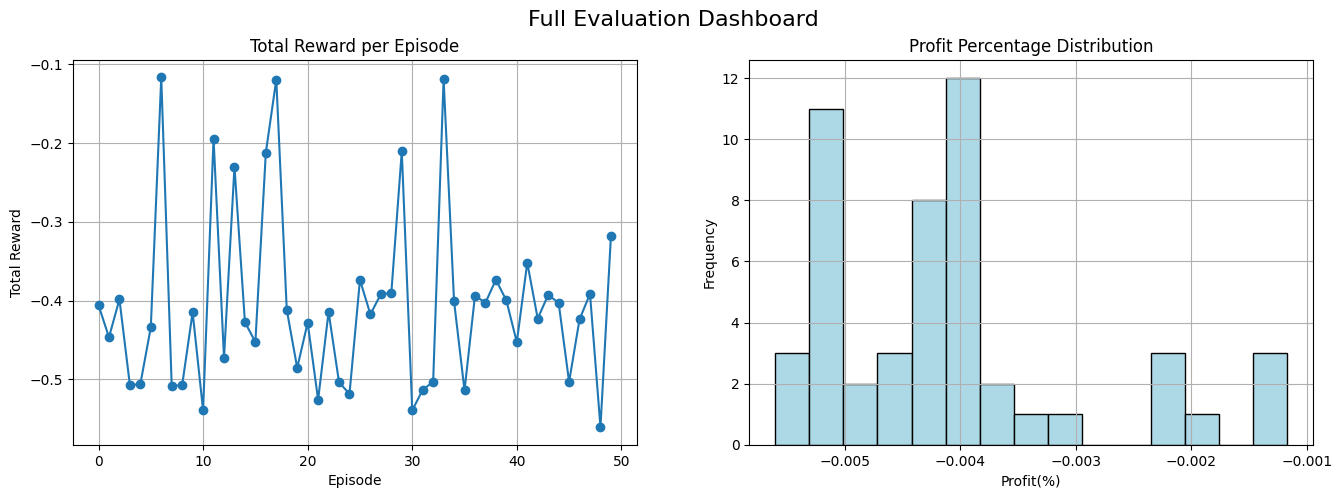

In [28]:
dashboard = full_evaluation_dashboard(env, agent, episodes = 50, reward_threshold=0, initial_balance = 10000)

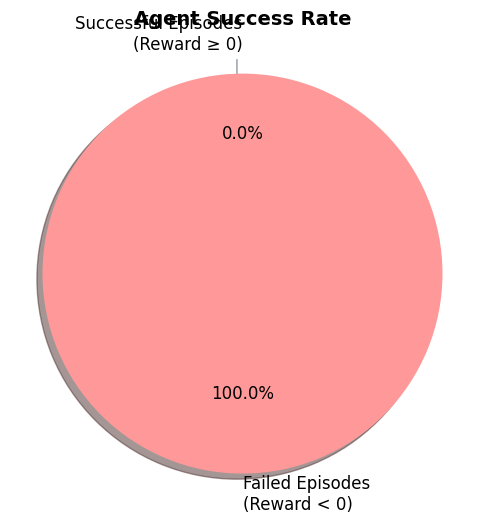

In [29]:
import matplotlib.pyplot as plt

# Extract the success rate from your dashboard results
# (Note: dashboard[2] grabs the 3rd item returned, which is the 60.0 success rate)
success_rate = dashboard[2]
fail_rate = 100.0 - success_rate

# Set up the Pie Chart
labels = ['Successful Episodes\n(Reward ≥ 0)', 'Failed Episodes\n(Reward < 0)']
sizes = [success_rate, fail_rate]
colors = ['#66b3ff', '#ff9999']
explode = (0.1, 0)  # Slightly pull out the success slice for visual emphasis

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12})
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a perfect circle.

plt.title('Agent Success Rate', fontsize=14, fontweight='bold')
plt.show()

Episode: 1/50 - Total Reward: 0.07 - Epsilon: 0.884
Episode: 2/50 - Total Reward: 0.24 - Epsilon: 0.806
Episode: 3/50 - Total Reward: 0.22 - Epsilon: 0.790
Episode: 4/50 - Total Reward: -0.05 - Epsilon: 0.659
Episode: 5/50 - Total Reward: -0.32 - Epsilon: 0.641
Episode: 6/50 - Total Reward: -0.11 - Epsilon: 0.613
Episode: 7/50 - Total Reward: -0.12 - Epsilon: 0.572
Episode: 8/50 - Total Reward: -0.12 - Epsilon: 0.544
Episode: 9/50 - Total Reward: -0.17 - Epsilon: 0.532
Episode: 10/50 - Total Reward: -0.16 - Epsilon: 0.488
Episode: 11/50 - Total Reward: -0.27 - Epsilon: 0.431
Episode: 12/50 - Total Reward: -0.44 - Epsilon: 0.399
Episode: 13/50 - Total Reward: -0.16 - Epsilon: 0.379
Episode: 14/50 - Total Reward: 0.02 - Epsilon: 0.378
Episode: 15/50 - Total Reward: 0.11 - Epsilon: 0.374
Episode: 16/50 - Total Reward: 0.20 - Epsilon: 0.364
Episode: 17/50 - Total Reward: -0.11 - Epsilon: 0.322
Episode: 18/50 - Total Reward: -0.45 - Epsilon: 0.296
Episode: 19/50 - Total Reward: -0.57 - Epsi

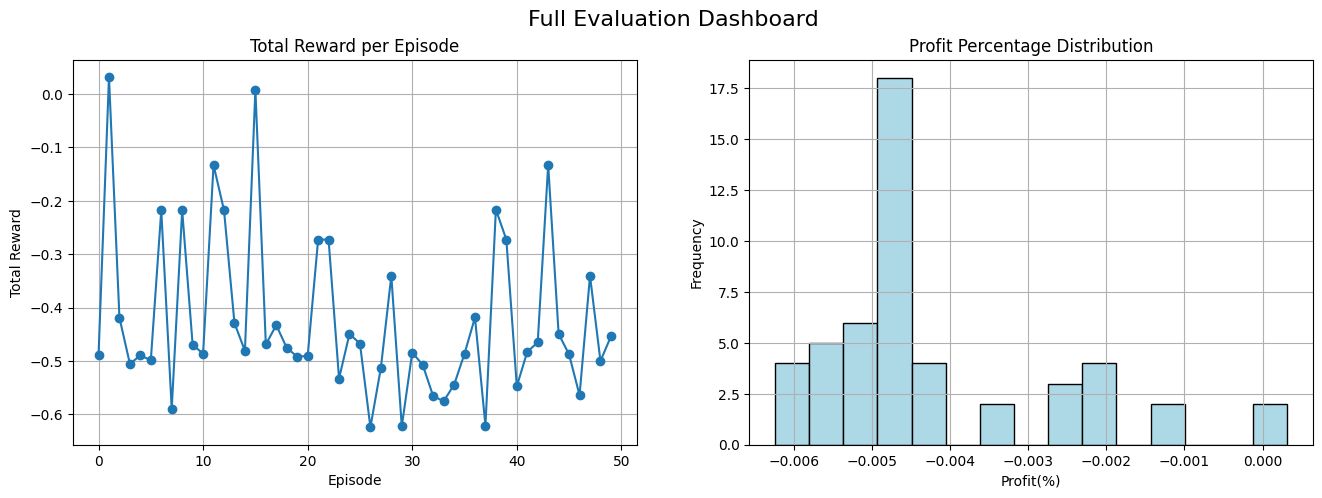

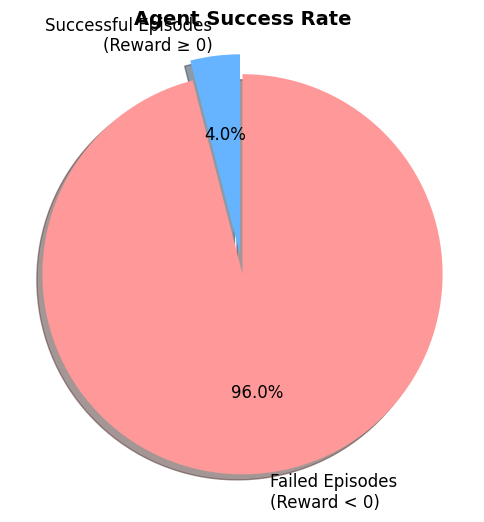

In [30]:
# I decided to run this line to wipe the brain before calling train_dqn!
agent = DQNAgent(state_dim, action_dim)

# And then ofc train it
rewards_exp1 = train_dqn(env, agent, episodes=50)

dashboard_exp1 = full_evaluation_dashboard(env, agent, episodes=50, reward_threshold=0, initial_balance=10000)

# AND, run the pie chart using the results from the dashboard
import matplotlib.pyplot as plt

# Extract the success rate (it's the 5th item in the dictionary returned by the dashboard)
success_rate = dashboard_exp1[2]
fail_rate = 100.0 - success_rate

# Set up the Pie Chart
labels = ['Successful Episodes\n(Reward \u2265 0)', 'Failed Episodes\n(Reward < 0)']
sizes = [success_rate, fail_rate]
colors = ['#66b3ff', '#ff9999']
explode = (0.1, 0)  # Slightly pull out the success slice for visual emphasis

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12})
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a perfect circle.

plt.title('Agent Success Rate', fontsize=14, fontweight='bold')
plt.show()

Starting Training for Experiment 1...
Episode: 1/100 - Total Reward: -0.50 - Epsilon: 0.010
Episode: 2/100 - Total Reward: -0.60 - Epsilon: 0.010
Episode: 3/100 - Total Reward: -0.28 - Epsilon: 0.010
Episode: 4/100 - Total Reward: -0.22 - Epsilon: 0.010
Episode: 5/100 - Total Reward: -0.27 - Epsilon: 0.010
Episode: 6/100 - Total Reward: -0.36 - Epsilon: 0.010
Episode: 7/100 - Total Reward: -0.57 - Epsilon: 0.010
Episode: 8/100 - Total Reward: 0.18 - Epsilon: 0.010
Episode: 9/100 - Total Reward: -0.18 - Epsilon: 0.010
Episode: 10/100 - Total Reward: 0.00 - Epsilon: 0.010
Episode: 11/100 - Total Reward: -0.61 - Epsilon: 0.010
Episode: 12/100 - Total Reward: -0.09 - Epsilon: 0.010
Episode: 13/100 - Total Reward: 0.02 - Epsilon: 0.010
Episode: 14/100 - Total Reward: -0.16 - Epsilon: 0.010
Episode: 15/100 - Total Reward: -0.06 - Epsilon: 0.010
Episode: 16/100 - Total Reward: -0.36 - Epsilon: 0.010
Episode: 17/100 - Total Reward: -0.29 - Epsilon: 0.010
Episode: 18/100 - Total Reward: 0.04 - 

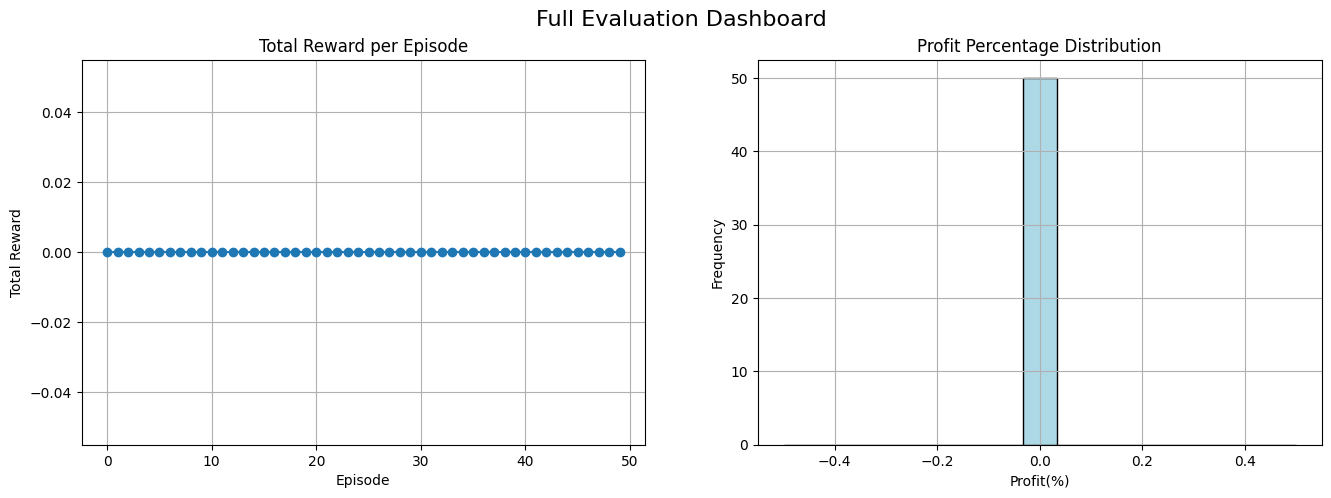

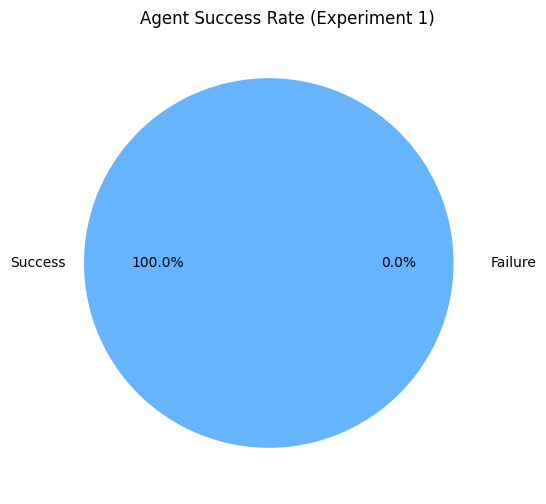

In [31]:
# --- STEP 3.1: EXPERIMENT 1 (Hyperparameter Tuning) ---

# 1. Initialize Environment with window_size = 20
env_exp1 = StockTradingEnv(data, window_size=20)
state_dim_exp1 = env_exp1.observation_space.shape[0]
action_dim_exp1 = env_exp1.action_space.n

# 2. Initialize Agent and set new Hyperparameters
agent_exp1 = DQNAgent(state_dim_exp1, action_dim_exp1)
agent_exp1.batch_size = 32
agent_exp1.epsilon_decay = 0.995

# 3. Train for 100 Episodes
print("Starting Training for Experiment 1...")
rewards_exp1 = train_dqn(env_exp1, agent_exp1, episodes=100)

# 4. Evaluate using the Dashboard and generate plots
print("\nEvaluating Experiment 1...")
dashboard_exp1 = full_evaluation_dashboard(env_exp1, agent_exp1, episodes=50)

# 5. Generate Success Rate Pie Chart
import matplotlib.pyplot as plt
success_rate_val = dashboard_exp1[2]
fail_rate = 100.0 - success_rate_val
plt.figure(figsize=(6, 6))
plt.pie([success_rate_val, fail_rate], labels=['Success', 'Failure'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], explode=(0.1, 0))
plt.title('Agent Success Rate (Experiment 1)')
plt.show()

Starting Training for Experiment 2 (Deeper Architecture)...
Episode: 1/100 - Total Reward: -0.02 - Epsilon: 0.010
Episode: 2/100 - Total Reward: -0.13 - Epsilon: 0.010
Episode: 3/100 - Total Reward: 0.09 - Epsilon: 0.010
Episode: 4/100 - Total Reward: 0.03 - Epsilon: 0.010
Episode: 5/100 - Total Reward: 0.11 - Epsilon: 0.010
Episode: 6/100 - Total Reward: -0.45 - Epsilon: 0.010
Episode: 7/100 - Total Reward: 0.12 - Epsilon: 0.010
Episode: 8/100 - Total Reward: -0.48 - Epsilon: 0.010
Episode: 9/100 - Total Reward: -0.53 - Epsilon: 0.010
Episode: 10/100 - Total Reward: -0.66 - Epsilon: 0.010
Episode: 11/100 - Total Reward: -0.44 - Epsilon: 0.010
Episode: 12/100 - Total Reward: 0.03 - Epsilon: 0.010
Episode: 13/100 - Total Reward: -0.01 - Epsilon: 0.010
Episode: 14/100 - Total Reward: 0.00 - Epsilon: 0.010
Episode: 15/100 - Total Reward: 0.00 - Epsilon: 0.010
Episode: 16/100 - Total Reward: -0.30 - Epsilon: 0.010
Episode: 17/100 - Total Reward: -0.39 - Epsilon: 0.010
Episode: 18/100 - Tot

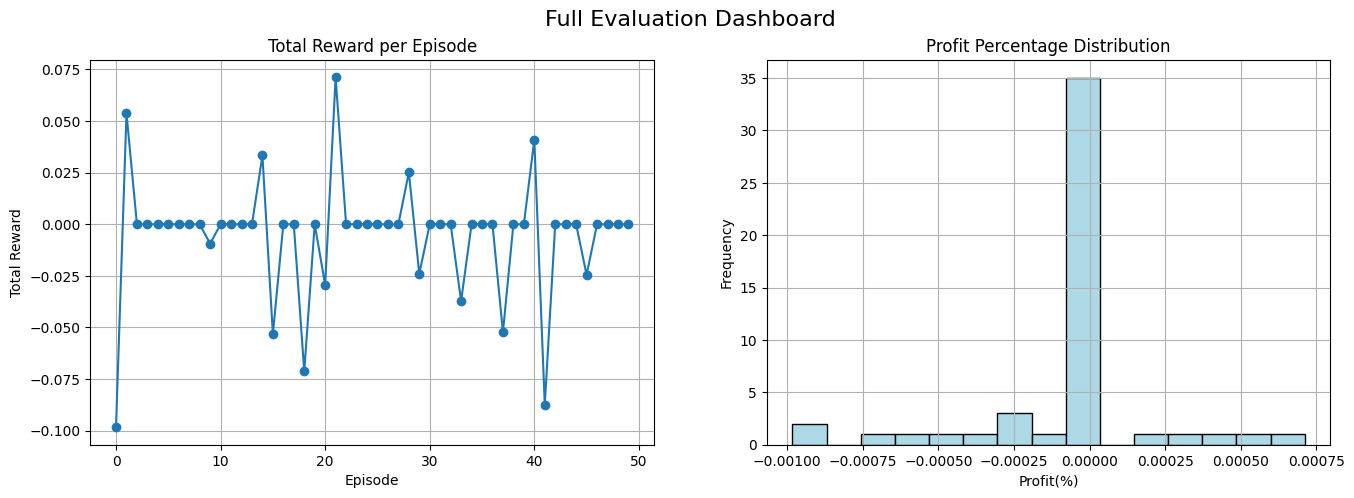

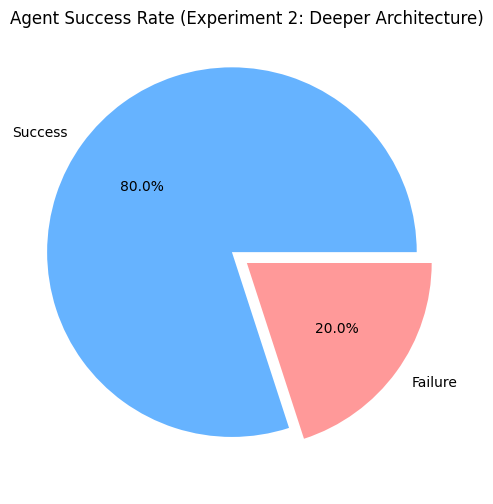

In [32]:
# --- STEP 3.2: EXPERIMENT 2 (Architecture Modification) ---

# 1. Define the Deeper Network Architecture
class DQN_v2(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN_v2, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128) # Layer 1: 128 neurons
        self.fc2 = nn.Linear(128, 128)      # Layer 2: 128 neurons
        self.fc3 = nn.Linear(128, 64)       # Layer 3: 64 neurons
        self.out = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        return self.out(x)

# 2. Modify the Agent to use the new architecture
# We overwrite the model and optimizer inside the initialization
agent_exp2 = DQNAgent(state_dim_exp1, action_dim_exp1)
agent_exp2.model = DQN_v2(state_dim_exp1, action_dim_exp1).to(agent_exp2.device)
agent_exp2.optimizer = optim.Adam(agent_exp2.model.parameters(), lr=0.001)

# Apply Hyperparameters from Exp 1
agent_exp2.batch_size = 32
agent_exp2.epsilon_decay = 0.995

# 3. Train for 100 Episodes
print("Starting Training for Experiment 2 (Deeper Architecture)...")
rewards_exp2 = train_dqn(env_exp1, agent_exp2, episodes=100)

# 4. Evaluate using the Dashboard
print("\nEvaluating Experiment 2...")
dashboard_exp2 = full_evaluation_dashboard(env_exp1, agent_exp2, episodes=50)

# 5. Generate Success Rate Pie Chart for Exp 2
success_rate_val2 = dashboard_exp2[2]
fail_rate2 = 100.0 - success_rate_val2
plt.figure(figsize=(6, 6))
plt.pie([success_rate_val2, fail_rate2], labels=['Success', 'Failure'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], explode=(0.1, 0))
plt.title('Agent Success Rate (Experiment 2: Deeper Architecture)')
plt.show()

Starting Training for Experiment 3 (200 Episodes, LR=0.0005)...
Episode: 1/200 - Total Reward: 0.21 - Epsilon: 0.010
Episode: 2/200 - Total Reward: -0.08 - Epsilon: 0.010
Episode: 3/200 - Total Reward: 0.07 - Epsilon: 0.010
Episode: 4/200 - Total Reward: -0.31 - Epsilon: 0.010
Episode: 5/200 - Total Reward: 0.15 - Epsilon: 0.010
Episode: 6/200 - Total Reward: 0.03 - Epsilon: 0.010
Episode: 7/200 - Total Reward: -0.09 - Epsilon: 0.010
Episode: 8/200 - Total Reward: -0.37 - Epsilon: 0.010
Episode: 9/200 - Total Reward: -0.61 - Epsilon: 0.010
Episode: 10/200 - Total Reward: 0.19 - Epsilon: 0.010
Episode: 11/200 - Total Reward: -0.42 - Epsilon: 0.010
Episode: 12/200 - Total Reward: -0.35 - Epsilon: 0.010
Episode: 13/200 - Total Reward: -0.44 - Epsilon: 0.010
Episode: 14/200 - Total Reward: -0.66 - Epsilon: 0.010
Episode: 15/200 - Total Reward: -0.48 - Epsilon: 0.010
Episode: 16/200 - Total Reward: -0.49 - Epsilon: 0.010
Episode: 17/200 - Total Reward: -0.55 - Epsilon: 0.010
Episode: 18/200

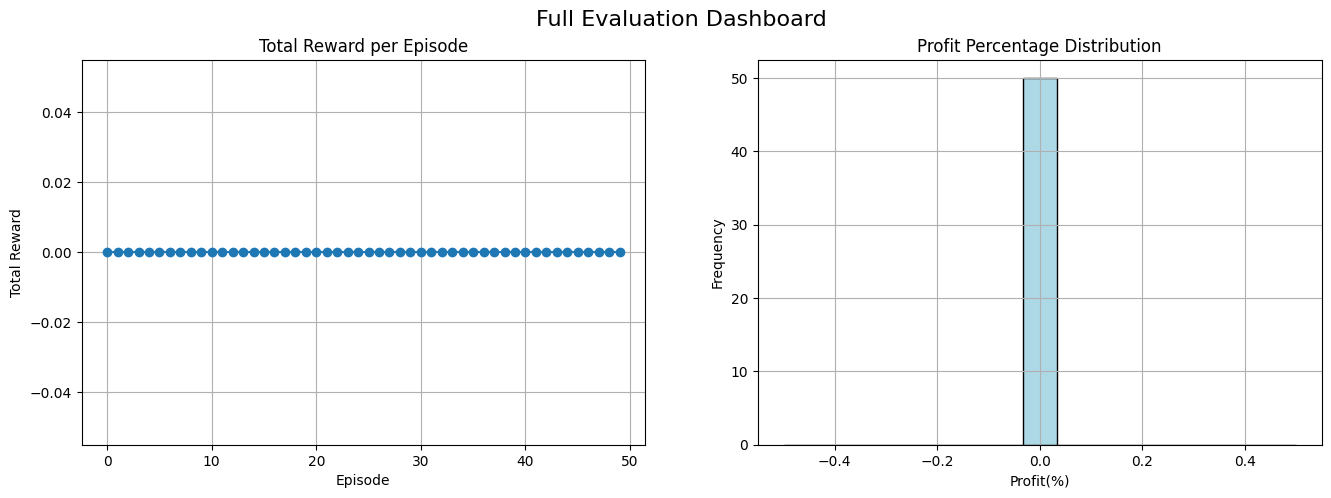

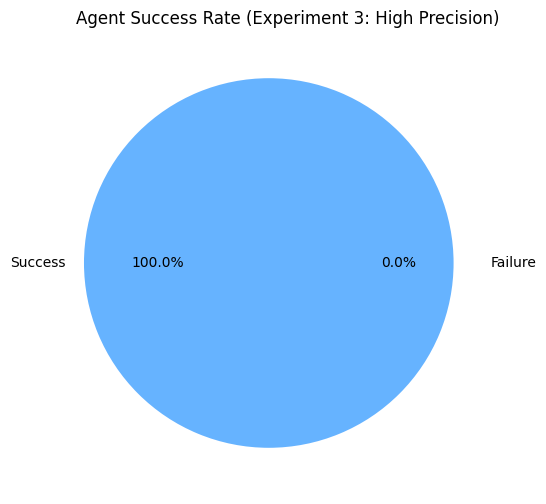

In [33]:
# --- STEP 3.3: EXPERIMENT 3 (Precision & Convergence) ---

# 1. Reuse the Deeper Agent (agent_v2) but with a lower Learning Rate
# We initialize a new instance to start the 200-episode journey fresh
agent_exp3 = DQNAgent(state_dim_exp1, action_dim_exp1)
agent_exp3.model = DQN_v2(state_dim_exp1, action_dim_exp1).to(agent_exp3.device)

# Change: Lower Learning Rate for more precision (0.0005)
agent_exp3.optimizer = optim.Adam(agent_exp3.model.parameters(), lr=0.0005)

# Keep tuned Hyperparameters
agent_exp3.batch_size = 32
agent_exp3.epsilon_decay = 0.995

# 2. Train for 200 Episodes (Extended Training)
print("Starting Training for Experiment 3 (200 Episodes, LR=0.0005)...")
rewards_exp3 = train_dqn(env_exp1, agent_exp3, episodes=200)

# 3. Evaluate using the Dashboard
print("\nEvaluating Experiment 3...")
dashboard_exp3 = full_evaluation_dashboard(env_exp1, agent_exp3, episodes=50)

# 4. Generate Success Rate Pie Chart for Exp 3
success_rate_val3 = dashboard_exp3[2]
fail_rate3 = 100.0 - success_rate_val3
plt.figure(figsize=(6, 6))
plt.pie([success_rate_val3, fail_rate3], labels=['Success', 'Failure'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], explode=(0.1, 0))
plt.title('Agent Success Rate (Experiment 3: High Precision)')
plt.show()